# Visualize trained deep-MPN weights across learning rules

Reload the deep-MPN (`dmpn`) networks saved by `train_mpn.py` (one seed, each
learning rule) and compare the three learned **weight matrices `W`** (not the
data-dependent modulation `M`):

| Component | Parameter | Shape | Role |
|---|---|---|---|
| **Input layer** | `W_initial_linear.weight` | `(n_embed, n_input)` | raw input → embedding |
| **Modulation-layer W** | `mp_layers[0].W` | `(n_hidden, n_embed)` | plastic MP weight (base of `W + W⊙M`) |
| **Output layer** | `W_output` | `(n_output, n_hidden)` | hidden → readout |

This is the RNN-comparable architecture (input → hidden → output), with the
plastic `M` playing the recurrence role. Set `SEED` / `RULES` below to match a
completed `train_mpn.py` run (checkpoints are assumed to be `dmpn`).

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

import _bootstrap  # noqa: F401  -- prepends ./core to sys.path
import mpn_tasks
import mpn
import train_mpn as tm

%matplotlib inline
plt.rcParams["figure.dpi"] = 110

## 1. Choose the run to load

`SEED` picks which trained network (seeds were `tm.SEED + k`). `RULES` must be a
subset of what `train_mpn.py` actually saved. The checkpoint path is built by
`tm.ckpt_path(rule, seed)` from the current `train_mpn` config — so if you
changed hidden size / steps / etc. for the run, set them on `tm` here first.

In [2]:
# --- run selection ---
SEED = tm.SEED            # e.g. 42; use tm.SEED + k for the k-th run
RULES = ["bptt", "local_diag_rflo", "local_direct"]  # rules to compare

# If the saved run used non-default config, override tm.* here BEFORE loading,
# e.g.  tm.N_HIDDEN = 200; tm.N_DATASETS = 5000
DEVICE = torch.device("cpu")

nets = {}
for rule in RULES:
    path = tm.ckpt_path(rule, SEED)
    nets[rule] = tm.load_net(path, device=DEVICE)
    print(f"{rule:20} <- {path}")

n_input = nets[RULES[0]].n_input
n_hidden = nets[RULES[0]].n_hidden
n_output = nets[RULES[0]].n_output
print(f"\nn_input={n_input}  n_hidden={n_hidden}  n_output={n_output}")

bptt                 <- /allen/programs/mindscope/workgroups/auto-model/zihan.zhang/mpn_local_learning/checkpoints/dmpn_delaygo_h200_b128_n5000_lr1e-03_exact_readout_eta1.00_lam0.99_bptt_seed42.pt
local_diag_rflo      <- /allen/programs/mindscope/workgroups/auto-model/zihan.zhang/mpn_local_learning/checkpoints/dmpn_delaygo_h200_b128_n5000_lr1e-03_exact_readout_eta1.00_lam0.99_local_diag_rflo_seed42.pt
local_direct         <- /allen/programs/mindscope/workgroups/auto-model/zihan.zhang/mpn_local_learning/checkpoints/dmpn_delaygo_h200_b128_n5000_lr1e-03_exact_readout_eta1.00_lam0.99_local_direct_seed42.pt

n_input=6  n_hidden=200  n_output=3


## 2. Extract the trained weight matrices

We visualize the learned **weights `W`** only (not the data-dependent modulation
`M`). For `dmpn` there are three: `W_initial_linear.weight` (input→embedding),
`mp_layers[0].W` (the plastic MP-layer weight), and `W_output` (readout).

In [3]:
comp = {}   # comp[rule] = {'W_in', 'W_mp', 'W_out'}
for rule, net in nets.items():
    W_in = net.W_initial_linear.weight.detach().cpu().numpy()  # (n_embed, n_input)
    W_mp = net.mp_layers[0].W.detach().cpu().numpy()            # (n_hidden, n_embed)
    W_out = net.W_output.detach().cpu().numpy()                 # (n_output, n_hidden)
    comp[rule] = {"W_in": W_in, "W_mp": W_mp, "W_out": W_out}
    print(f"{rule:20} |W_in| {np.abs(W_in).mean():.3e}  "
          f"|W_mp| {np.abs(W_mp).mean():.3e}  |W_out| {np.abs(W_out).mean():.3e}")

bptt                 |W_in| 1.057e-01  |W_mp| 6.310e-02  |W_out| 8.437e-02
local_diag_rflo      |W_in| 8.647e-02  |W_mp| 6.414e-02  |W_out| 8.484e-02
local_direct         |W_in| 8.702e-02  |W_mp| 6.499e-02  |W_out| 8.618e-02


## 3. Weight heatmaps — one row per learning rule

Columns: **input layer** `W_initial_linear`, **modulation-layer** `mp_layers[0].W`,
and **output layer** `W_output`. A shared symmetric color scale per column makes
rules directly comparable.

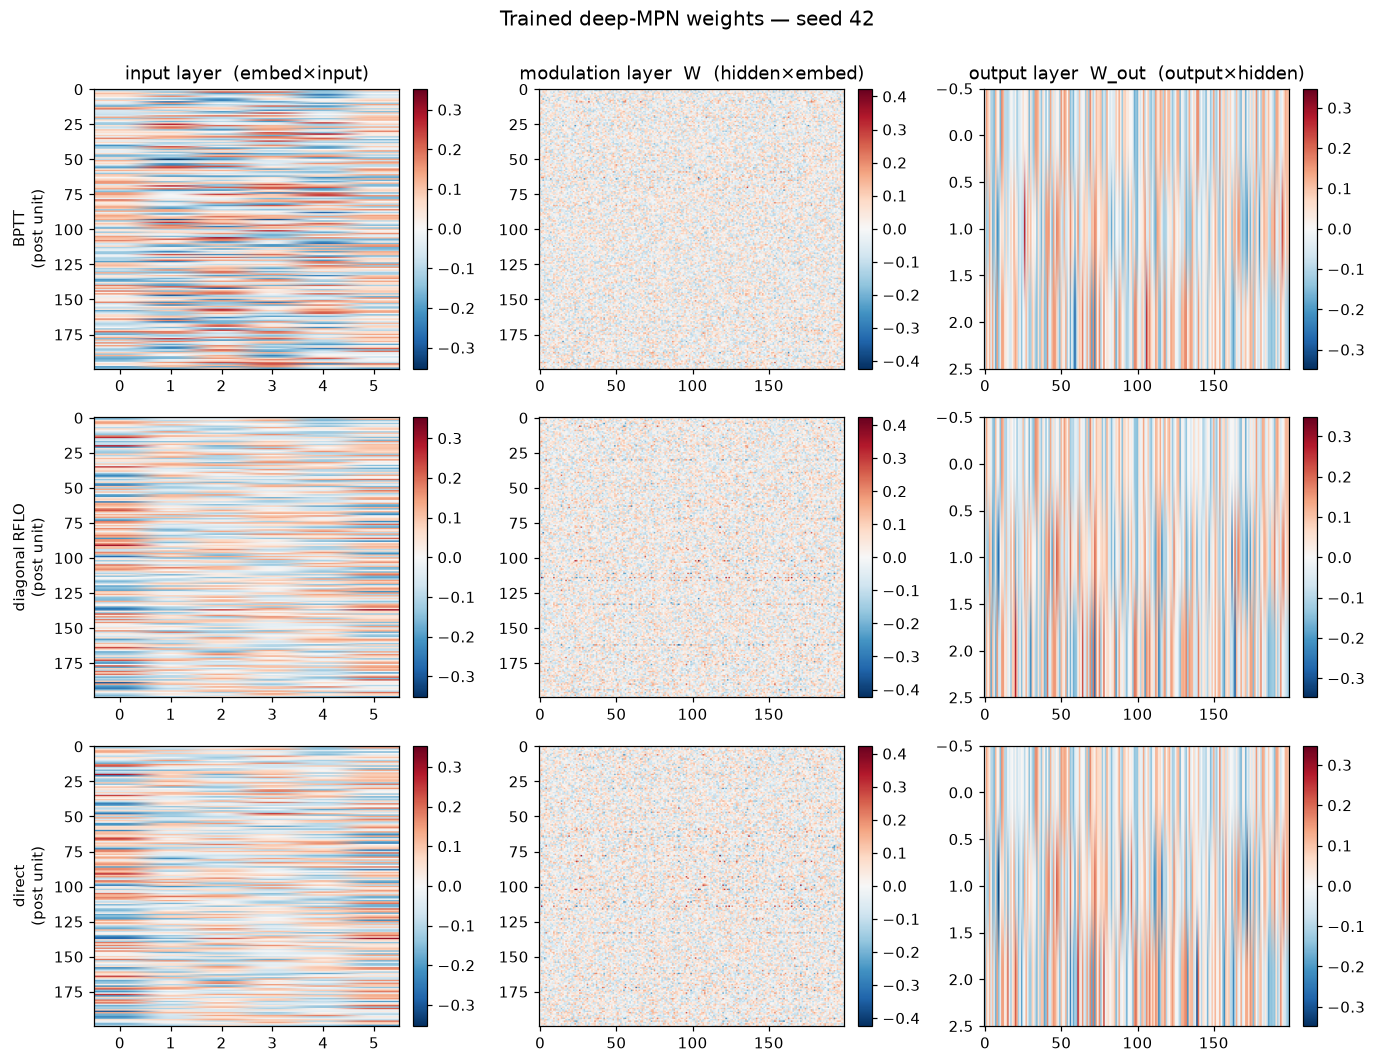

In [4]:
cols = [("W_in", "input layer  (embed×input)"),
        ("W_mp", "modulation layer  W  (hidden×embed)"),
        ("W_out", "output layer  W_out  (output×hidden)")]

# Shared symmetric vlim per column (comparable across rules).
vlim = {}
for key, _ in cols:
    m = max(np.abs(comp[r][key]).max() for r in RULES)
    vlim[key] = m

nrows, ncols = len(RULES), len(cols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.2 * nrows),
                         squeeze=False)
for i, rule in enumerate(RULES):
    for j, (key, title) in enumerate(cols):
        ax = axes[i][j]
        v = vlim[key]
        im = ax.imshow(comp[rule][key], aspect="auto", cmap="RdBu_r",
                       vmin=-v, vmax=v)
        if i == 0:
            ax.set_title(title)
        if j == 0:
            ax.set_ylabel(f"{tm.RULE_LABEL.get(rule, rule)}\n(post unit)", fontsize=10)
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle(f"Trained deep-MPN weights — seed {SEED}", y=1.002, fontsize=13)
fig.tight_layout()
plt.show()

## 4. Weight distributions (overlaid histograms)

For each weight matrix, overlay the flattened weight distributions of
the learning rules on shared bins. This shows how the *shape/spread* of
the learned weights differs across rules (e.g. whether a local rule
learns systematically larger / more sparse weights than BPTT), which the
heatmaps above don't make quantitative.

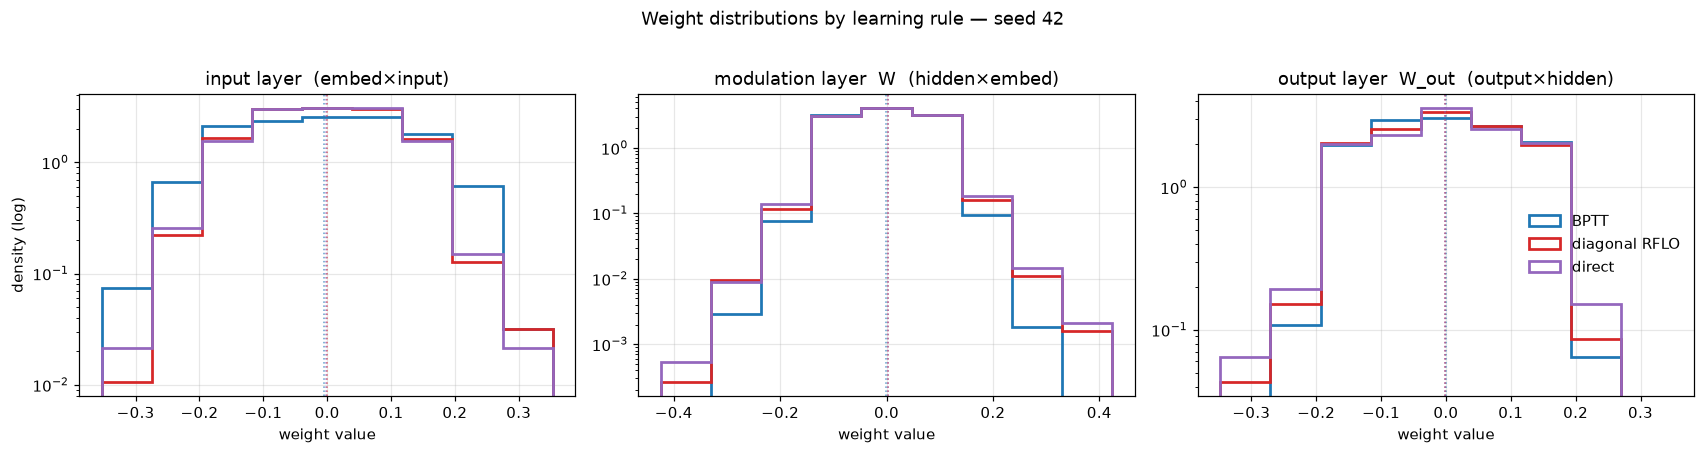

component  rule                  mean       std    max|w|
W_in       BPTT             -5.591e-03 1.251e-01 3.532e-01
W_in       diagonal RFLO    -1.041e-03 1.027e-01 3.018e-01
W_in       direct           -1.857e-03 1.038e-01 3.053e-01
W_mp       BPTT             -3.190e-04 7.387e-02 2.936e-01
W_mp       diagonal RFLO    1.862e-03 7.607e-02 4.051e-01
W_mp       direct           1.915e-03 7.722e-02 4.240e-01
W_out      BPTT             1.582e-04 9.929e-02 2.691e-01
W_out      diagonal RFLO    -7.980e-04 1.018e-01 2.723e-01
W_out      direct           -8.395e-04 1.045e-01 3.477e-01


In [5]:
fig, axes = plt.subplots(1, len(cols), figsize=(5.2 * len(cols), 4.0),
                         squeeze=False)
for j, (key, title) in enumerate(cols):
    ax = axes[0][j]
    # Shared symmetric bins across rules for a fair overlay.
    vmax = max(np.abs(comp[r][key]).max() for r in RULES)
    bins = np.linspace(-vmax, vmax, 10)
    for rule in RULES:
        w = comp[rule][key].ravel()
        ax.hist(w, bins=bins, density=True, histtype='step', linewidth=1.8,
                color=tm.RULE_COLOR.get(rule), label=tm.RULE_LABEL.get(rule, rule))
        ax.axvline(w.mean(), color=tm.RULE_COLOR.get(rule), ls=':', lw=1, alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel('weight value')
    ax.set_yscale('log')  # heavy tails vs bulk both visible
    ax.grid(alpha=0.3)
axes[0][0].set_ylabel('density (log)')
axes[0][-1].legend(frameon=False)
fig.suptitle(f'Weight distributions by learning rule — seed {SEED}', y=1.02)
fig.tight_layout()
plt.show()

# Per-rule distribution statistics (std, and fraction of |w| near zero).
print(f"{'component':10} {'rule':16} {'mean':>9} {'std':>9} {'max|w|':>9}")
for key, _ in cols:
    for rule in RULES:
        w = comp[rule][key].ravel()
        print(f'{key:10} {tm.RULE_LABEL.get(rule, rule):16} '
              f'{w.mean():>9.3e} {w.std():>9.3e} {np.abs(w).max():>9.3e}')